# Vega-Lite is declarative; Matplotlib is imperative

Vega-Lite specs say *what* a plot is: a dataset, a mark type, a few encoding channels. Matplotlib code says *how* to draw it: figures, axes, calls to `bar` / `scatter` / `plot`, label setters, legend bookkeeping. Most of the time you pick one and stick with it. But sometimes you want to translate.

A few reasons this is useful:

- Authors generate Vega-Lite via Altair / Observable / dashboards, then need plain Matplotlib to drop the figure into a LaTeX paper.
- Vega-Lite is a great compact way to *describe* a plot — you can save a one-line JSON and regenerate. Matplotlib code is a great compact way to *edit* a plot — fonts, ticks, twin axes, callouts.
- It's a fun excuse to write a tiny compiler.

This post does the most direct version of that: a small function that takes a Vega-Lite spec dict and returns a string of Matplotlib code. We then `exec` the generated code to render the figure, so you can compare:

1. the **original Vega-Lite spec** rendered by Altair,
2. the **generated Matplotlib code** as inspectable Python,
3. the **rendered Matplotlib figure**.

The translator covers a handful of marks (`bar`, `point`/`circle`, `line`) and a few encoding channels (`x`, `y`, `color`, plus titles). It is deliberately under 100 lines. Anything beyond — facets, layers, transforms, scales, time axes — would need a real visitor pattern, which is out of scope here.

## Setup

We need Altair to render the original Vega-Lite specs, Matplotlib to render the translated ones, and pandas because that's how Matplotlib likes to receive tabular data.

In [1]:
import json

import altair as alt
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

%matplotlib inline
%config InlineBackend.figure_format = "retina"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

alt.data_transformers.disable_max_rows()
print("altair", alt.__version__)

altair 6.0.0


## The translator

The function below takes a parsed Vega-Lite spec (a Python dict) and returns a string of standalone Matplotlib code. It assumes inline data (`spec["data"]["values"]`) and dispatches on `spec["mark"]`.

Two small helpers:

- `enc_label(channel)` builds an axis label, preferring an explicit `title` on the encoding and falling back to the field name.
- `mark_type(spec)` accepts either `"bar"` or `{"type": "bar", ...}` since Vega-Lite allows both forms.

The output is intentionally line-by-line and readable, not minified. The whole point is that you can paste the generated code into a script.

In [2]:
def mark_type(spec):
    mark = spec.get("mark")
    return mark if isinstance(mark, str) else mark.get("type")


def enc_label(enc_channel):
    if "title" in enc_channel:
        return enc_channel["title"]
    return enc_channel.get("field", "")


def vegalite_to_matplotlib(spec):
    """Translate a Vega-Lite dict into a string of Matplotlib code.

    Supports: mark in {bar, point, circle, line}; encodings x, y, optional color
    (treated as a categorical group). Inline data only.
    """
    enc = spec.get("encoding", {})
    if "x" not in enc or "y" not in enc:
        raise ValueError("Spec must define both x and y encodings")

    mark = mark_type(spec)
    x_field = enc["x"]["field"]
    y_field = enc["y"]["field"]
    color_field = enc.get("color", {}).get("field")

    rows = spec["data"]["values"]
    title = spec.get("title")

    lines = [
        "import matplotlib.pyplot as plt",
        "import pandas as pd",
        "",
        f"data = {json.dumps(rows)}",
        "df = pd.DataFrame(data)",
        "fig, ax = plt.subplots(figsize=(6, 3.6))",
        "",
    ]

    if mark == "bar":
        if color_field is None:
            lines.append(f"ax.bar(df[{x_field!r}], df[{y_field!r}])")
        else:
            # grouped bars by color field
            lines += [
                f"groups = list(dict.fromkeys(df[{color_field!r}]))",
                f"x_vals = list(dict.fromkeys(df[{x_field!r}]))",
                "import numpy as np",
                "x_idx = np.arange(len(x_vals))",
                "width = 0.8 / max(1, len(groups))",
                "for i, g in enumerate(groups):",
                f"    sub = df[df[{color_field!r}] == g]",
                f"    ys = [sub[sub[{x_field!r}] == xv][{y_field!r}].sum() for xv in x_vals]",
                "    ax.bar(x_idx + i * width - 0.4 + width / 2, ys, width, label=str(g))",
                "ax.set_xticks(x_idx)",
                "ax.set_xticklabels(x_vals)",
                f"ax.legend(title={color_field!r})",
            ]
    elif mark in ("point", "circle"):
        if color_field is None:
            lines.append(f"ax.scatter(df[{x_field!r}], df[{y_field!r}], s=24)")
        else:
            lines += [
                f"for label, sub in df.groupby({color_field!r}):",
                f"    ax.scatter(sub[{x_field!r}], sub[{y_field!r}], s=24, label=label)",
                f"ax.legend(title={color_field!r})",
            ]
    elif mark == "line":
        if color_field is None:
            lines.append(f"ax.plot(df[{x_field!r}], df[{y_field!r}], marker='o')")
        else:
            lines += [
                f"for label, sub in df.groupby({color_field!r}):",
                f"    ax.plot(sub[{x_field!r}], sub[{y_field!r}], marker='o', label=label)",
                f"ax.legend(title={color_field!r})",
            ]
    else:
        raise NotImplementedError(f"mark {mark!r} not supported")

    lines += [
        "",
        f"ax.set_xlabel({enc_label(enc['x'])!r})",
        f"ax.set_ylabel({enc_label(enc['y'])!r})",
    ]
    if title:
        lines.append(f"ax.set_title({title!r})")
    lines += ["fig.tight_layout()", "plt.show()"]

    return "\n".join(lines)


def render_generated(code):
    """Execute the generated code in a clean namespace."""
    ns = {}
    exec(compile(code, "<generated-mpl>", "exec"), ns)


def show_side_by_side(spec):
    print("--- generated Matplotlib code ---")
    code = vegalite_to_matplotlib(spec)
    print(code)
    print("--- Altair render of the original spec ---")
    display(alt.Chart.from_dict(spec).properties(width=320, height=200))
    print("--- Matplotlib render of the generated code ---")
    render_generated(code)

## Example 1: a bar chart

The Vega-Lite tutorial chart, almost verbatim.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import pandas as pd

data = [{"category": "A", "value": 28}, {"category": "B", "value": 55}, {"category": "C", "value": 43}, {"category": "D", "value": 91}, {"category": "E", "value": 81}, {"category": "F", "value": 53}, {"category": "G", "value": 19}, {"category": "H", "value": 87}]
df = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(6, 3.6))

ax.bar(df['category'], df['value'])

ax.set_xlabel('Category')
ax.set_ylabel('Value')
ax.set_title('A bar chart')
fig.tight_layout()
plt.show()
--- Altair render of the original spec ---


alt.Chart(...)

--- Matplotlib render of the generated code ---


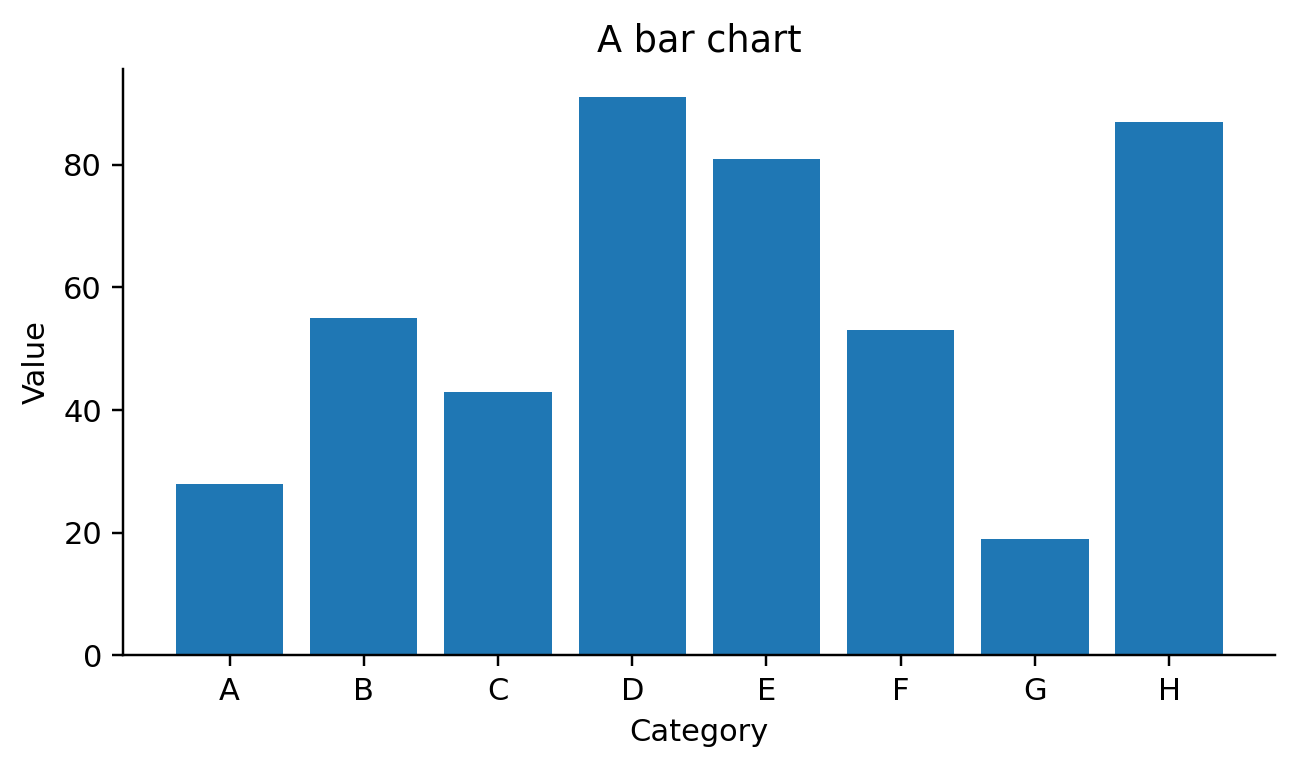

In [3]:
spec_bar = {
    "data": {"values": [
        {"category": "A", "value": 28},
        {"category": "B", "value": 55},
        {"category": "C", "value": 43},
        {"category": "D", "value": 91},
        {"category": "E", "value": 81},
        {"category": "F", "value": 53},
        {"category": "G", "value": 19},
        {"category": "H", "value": 87},
    ]},
    "mark": "bar",
    "encoding": {
        "x": {"field": "category", "type": "nominal", "title": "Category"},
        "y": {"field": "value", "type": "quantitative", "title": "Value"},
    },
    "title": "A bar chart",
}

show_side_by_side(spec_bar)

## Example 2: a plain scatter

Quantitative on both axes, no color encoding. Translates to one `ax.scatter` call.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import pandas as pd

data = [{"hp": 130, "mpg": 18.0}, {"hp": 165, "mpg": 15.0}, {"hp": 150, "mpg": 18.0}, {"hp": 95, "mpg": 24.0}, {"hp": 70, "mpg": 27.0}, {"hp": 198, "mpg": 14.0}, {"hp": 88, "mpg": 27.0}, {"hp": 215, "mpg": 10.0}, {"hp": 105, "mpg": 22.0}, {"hp": 75, "mpg": 26.0}]
df = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(6, 3.6))

ax.scatter(df['hp'], df['mpg'], s=24)

ax.set_xlabel('Horsepower')
ax.set_ylabel('Miles per gallon')
ax.set_title('Cars: HP vs MPG')
fig.tight_layout()
plt.show()
--- Altair render of the original spec ---


alt.Chart(...)

--- Matplotlib render of the generated code ---


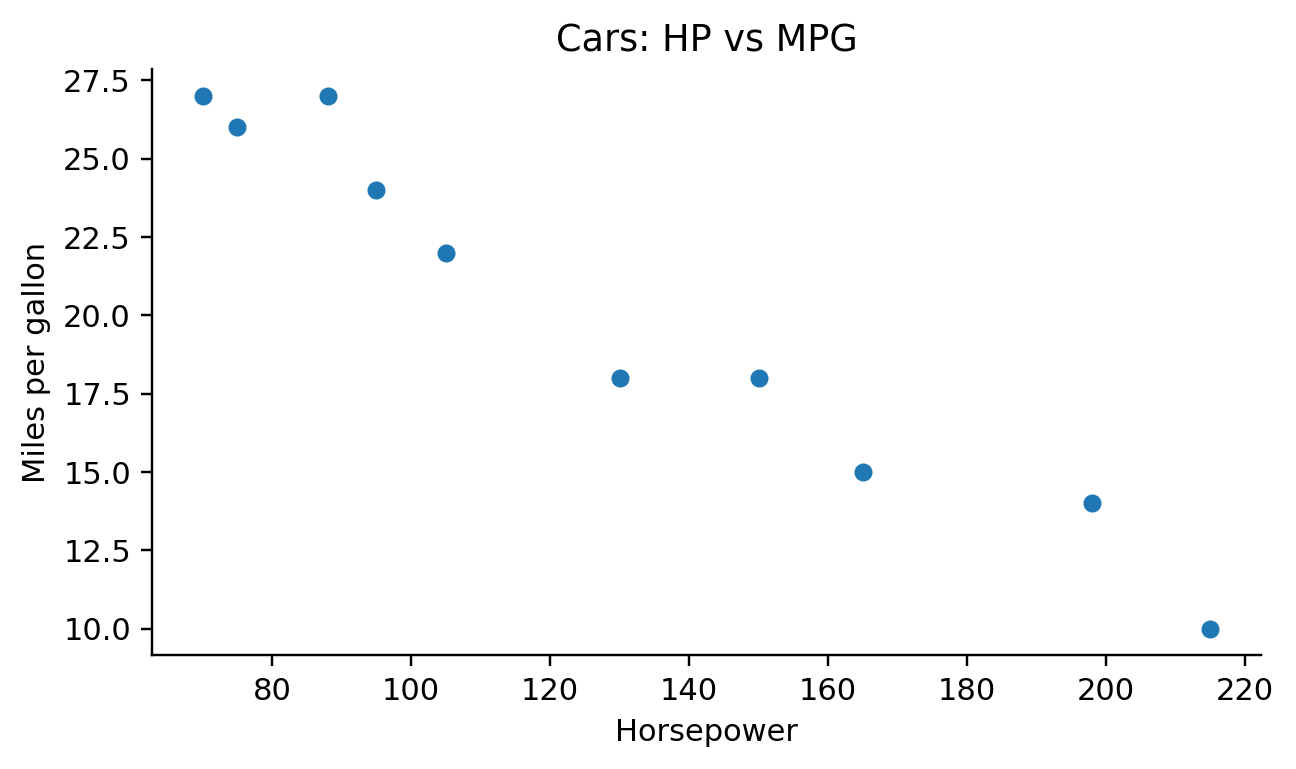

In [4]:
spec_scatter = {
    "data": {"values": [
        {"hp": 130, "mpg": 18.0},
        {"hp": 165, "mpg": 15.0},
        {"hp": 150, "mpg": 18.0},
        {"hp": 95,  "mpg": 24.0},
        {"hp": 70,  "mpg": 27.0},
        {"hp": 198, "mpg": 14.0},
        {"hp": 88,  "mpg": 27.0},
        {"hp": 215, "mpg": 10.0},
        {"hp": 105, "mpg": 22.0},
        {"hp": 75,  "mpg": 26.0},
    ]},
    "mark": "point",
    "encoding": {
        "x": {"field": "hp", "type": "quantitative", "title": "Horsepower"},
        "y": {"field": "mpg", "type": "quantitative", "title": "Miles per gallon"},
    },
    "title": "Cars: HP vs MPG",
}

show_side_by_side(spec_scatter)

## Example 3: scatter with a categorical color encoding

This is where the translator earns its keep — `color` becomes a `groupby` plus a per-group `ax.scatter` call plus a legend. Vega-Lite would do all three from `"color": {"field": ...}`.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import pandas as pd

data = [{"hp": 130, "mpg": 18.0, "origin": "USA"}, {"hp": 165, "mpg": 15.0, "origin": "USA"}, {"hp": 150, "mpg": 18.0, "origin": "USA"}, {"hp": 95, "mpg": 24.0, "origin": "Japan"}, {"hp": 70, "mpg": 27.0, "origin": "Japan"}, {"hp": 88, "mpg": 27.0, "origin": "Japan"}, {"hp": 75, "mpg": 26.0, "origin": "Europe"}, {"hp": 105, "mpg": 22.0, "origin": "Europe"}, {"hp": 110, "mpg": 21.0, "origin": "Europe"}]
df = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(6, 3.6))

for label, sub in df.groupby('origin'):
    ax.scatter(sub['hp'], sub['mpg'], s=24, label=label)
ax.legend(title='origin')

ax.set_xlabel('Horsepower')
ax.set_ylabel('Miles per gallon')
ax.set_title('Cars by origin')
fig.tight_layout()
plt.show()
--- Altair render of the original spec ---


alt.Chart(...)

--- Matplotlib render of the generated code ---


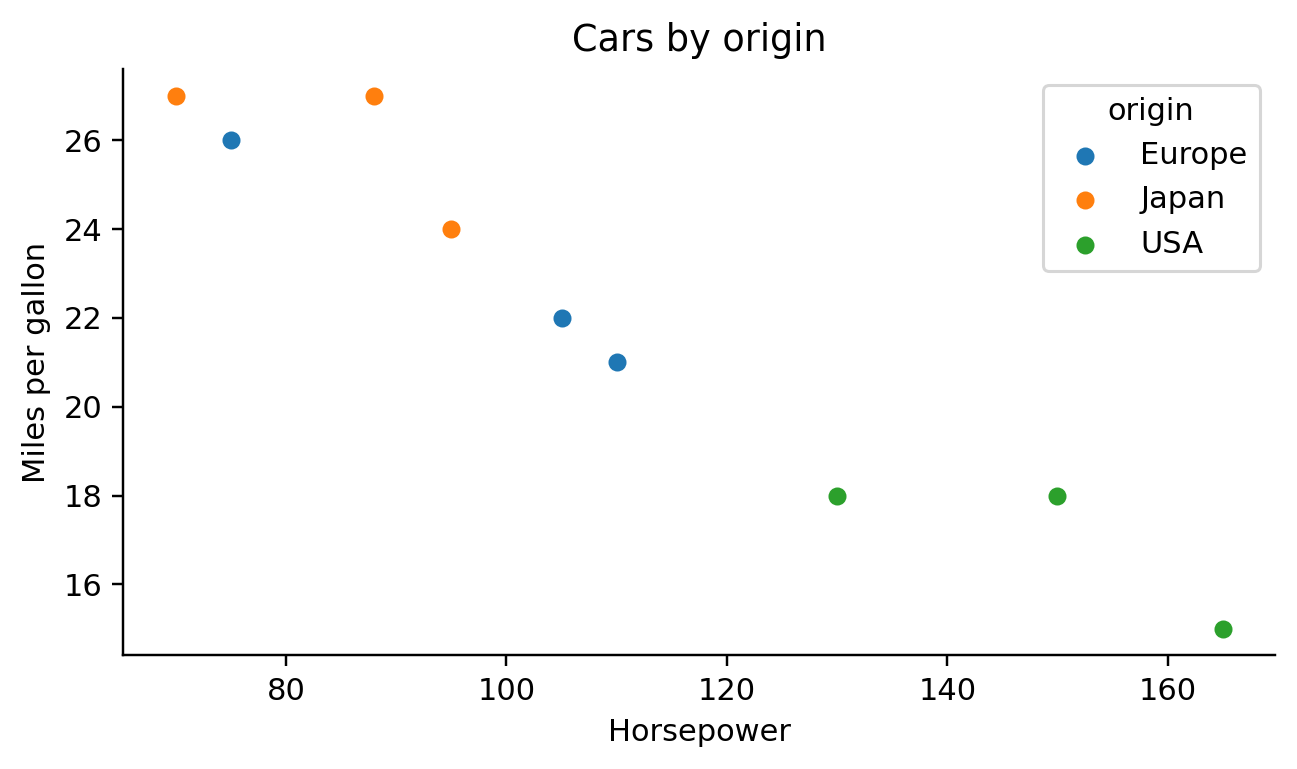

In [5]:
spec_scatter_color = {
    "data": {"values": [
        {"hp": 130, "mpg": 18.0, "origin": "USA"},
        {"hp": 165, "mpg": 15.0, "origin": "USA"},
        {"hp": 150, "mpg": 18.0, "origin": "USA"},
        {"hp": 95,  "mpg": 24.0, "origin": "Japan"},
        {"hp": 70,  "mpg": 27.0, "origin": "Japan"},
        {"hp": 88,  "mpg": 27.0, "origin": "Japan"},
        {"hp": 75,  "mpg": 26.0, "origin": "Europe"},
        {"hp": 105, "mpg": 22.0, "origin": "Europe"},
        {"hp": 110, "mpg": 21.0, "origin": "Europe"},
    ]},
    "mark": "point",
    "encoding": {
        "x": {"field": "hp", "type": "quantitative", "title": "Horsepower"},
        "y": {"field": "mpg", "type": "quantitative", "title": "Miles per gallon"},
        "color": {"field": "origin", "type": "nominal"},
    },
    "title": "Cars by origin",
}

show_side_by_side(spec_scatter_color)

## Example 4: a line chart with grouped series

Same shape as Example 3, but `mark` is `line`, so the translator emits `ax.plot` per group.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import pandas as pd

data = [{"month": "Jan", "city": "Bengaluru", "rainfall_mm": 2}, {"month": "Feb", "city": "Bengaluru", "rainfall_mm": 6}, {"month": "Mar", "city": "Bengaluru", "rainfall_mm": 11}, {"month": "Apr", "city": "Bengaluru", "rainfall_mm": 38}, {"month": "May", "city": "Bengaluru", "rainfall_mm": 105}, {"month": "Jun", "city": "Bengaluru", "rainfall_mm": 88}, {"month": "Jan", "city": "Mumbai", "rainfall_mm": 0}, {"month": "Feb", "city": "Mumbai", "rainfall_mm": 0}, {"month": "Mar", "city": "Mumbai", "rainfall_mm": 0}, {"month": "Apr", "city": "Mumbai", "rainfall_mm": 1}, {"month": "May", "city": "Mumbai", "rainfall_mm": 12}, {"month": "Jun", "city": "Mumbai", "rainfall_mm": 540}]
df = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(6, 3.6))

for label, sub in df.groupby('city'):
    ax.plot(sub['month'], sub['rainfall_mm'], marker='o', label=label)
ax.legend(title='city')

ax.set_xlabel('Month')
ax.set_y

alt.Chart(...)

--- Matplotlib render of the generated code ---


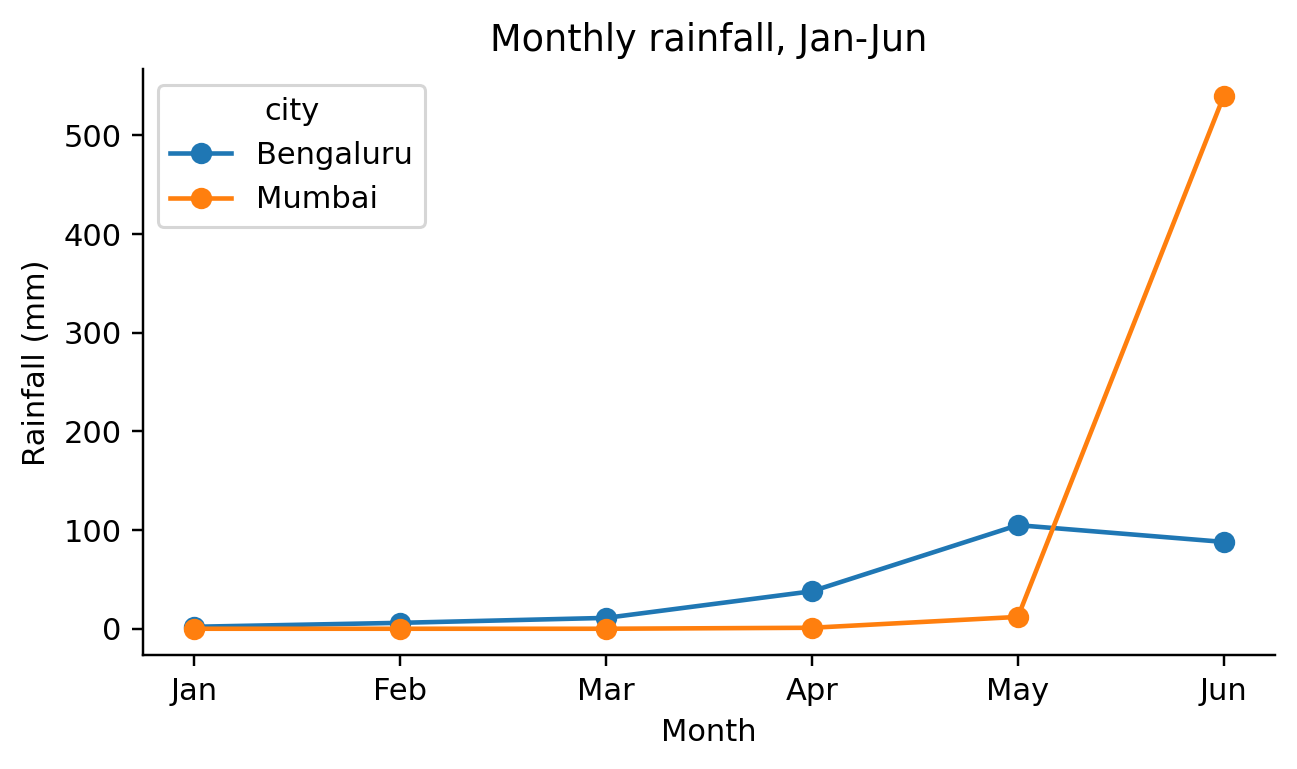

In [6]:
spec_line = {
    "data": {"values": [
        {"month": "Jan", "city": "Bengaluru", "rainfall_mm": 2},
        {"month": "Feb", "city": "Bengaluru", "rainfall_mm": 6},
        {"month": "Mar", "city": "Bengaluru", "rainfall_mm": 11},
        {"month": "Apr", "city": "Bengaluru", "rainfall_mm": 38},
        {"month": "May", "city": "Bengaluru", "rainfall_mm": 105},
        {"month": "Jun", "city": "Bengaluru", "rainfall_mm": 88},
        {"month": "Jan", "city": "Mumbai", "rainfall_mm": 0},
        {"month": "Feb", "city": "Mumbai", "rainfall_mm": 0},
        {"month": "Mar", "city": "Mumbai", "rainfall_mm": 0},
        {"month": "Apr", "city": "Mumbai", "rainfall_mm": 1},
        {"month": "May", "city": "Mumbai", "rainfall_mm": 12},
        {"month": "Jun", "city": "Mumbai", "rainfall_mm": 540},
    ]},
    "mark": "line",
    "encoding": {
        "x": {"field": "month", "type": "ordinal", "title": "Month"},
        "y": {"field": "rainfall_mm", "type": "quantitative", "title": "Rainfall (mm)"},
        "color": {"field": "city", "type": "nominal"},
    },
    "title": "Monthly rainfall, Jan-Jun",
}

show_side_by_side(spec_line)

## Example 5: grouped bars

The translator handles this via the same `color` channel: each group becomes a side-by-side bar series. Vega-Lite would default to stacked bars instead, but for a tiny converter, side-by-side is the more useful default.

--- generated Matplotlib code ---
import matplotlib.pyplot as plt
import pandas as pd

data = [{"quarter": "Q1", "team": "A", "score": 12}, {"quarter": "Q2", "team": "A", "score": 17}, {"quarter": "Q3", "team": "A", "score": 9}, {"quarter": "Q4", "team": "A", "score": 14}, {"quarter": "Q1", "team": "B", "score": 8}, {"quarter": "Q2", "team": "B", "score": 19}, {"quarter": "Q3", "team": "B", "score": 15}, {"quarter": "Q4", "team": "B", "score": 11}]
df = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(6, 3.6))

groups = list(dict.fromkeys(df['team']))
x_vals = list(dict.fromkeys(df['quarter']))
import numpy as np
x_idx = np.arange(len(x_vals))
width = 0.8 / max(1, len(groups))
for i, g in enumerate(groups):
    sub = df[df['team'] == g]
    ys = [sub[sub['quarter'] == xv]['score'].sum() for xv in x_vals]
    ax.bar(x_idx + i * width - 0.4 + width / 2, ys, width, label=str(g))
ax.set_xticks(x_idx)
ax.set_xticklabels(x_vals)
ax.legend(title='team')

ax.set_xlabel('Quarter')
ax.set_ylab

alt.Chart(...)

--- Matplotlib render of the generated code ---


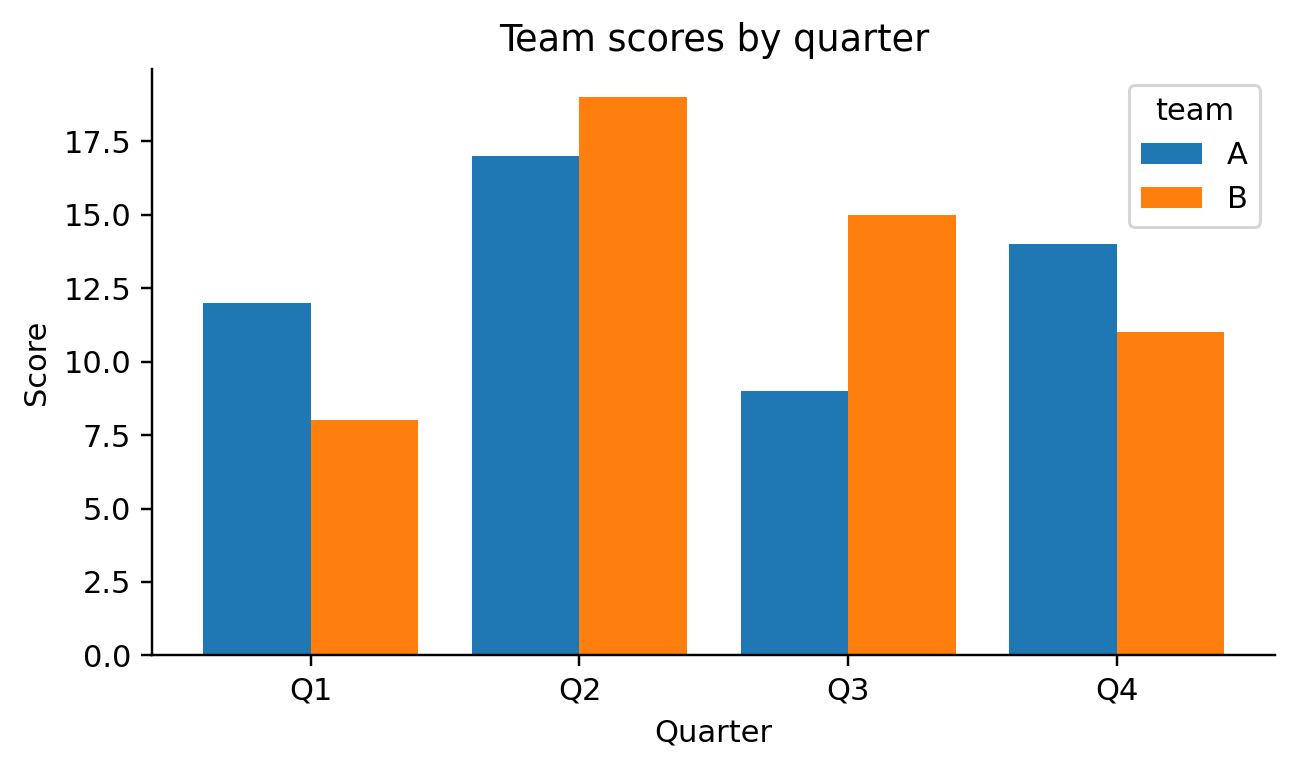

In [7]:
spec_grouped = {
    "data": {"values": [
        {"quarter": "Q1", "team": "A", "score": 12},
        {"quarter": "Q2", "team": "A", "score": 17},
        {"quarter": "Q3", "team": "A", "score": 9},
        {"quarter": "Q4", "team": "A", "score": 14},
        {"quarter": "Q1", "team": "B", "score": 8},
        {"quarter": "Q2", "team": "B", "score": 19},
        {"quarter": "Q3", "team": "B", "score": 15},
        {"quarter": "Q4", "team": "B", "score": 11},
    ]},
    "mark": "bar",
    "encoding": {
        "x": {"field": "quarter", "type": "nominal", "title": "Quarter"},
        "y": {"field": "score", "type": "quantitative", "title": "Score"},
        "color": {"field": "team", "type": "nominal"},
    },
    "title": "Team scores by quarter",
}

show_side_by_side(spec_grouped)

## What the toy translator does *not* do

Deliberately out of scope:

- **Aggregations and transforms.** Vega-Lite has `transform: [{aggregate: "mean", ...}]` and field-level `aggregate: "mean"`. The translator would need to emit a `groupby().agg()` step before the plot.
- **Scales.** Log scales, custom domains, time scales, secondary axes — all need `ax.set_xscale`, `ax.set_xlim`, `mdates`. Easy to add per channel.
- **Faceting / layering / concatenation.** Real compiling territory: a Vega-Lite spec can be a tree of `layer`, `hconcat`, `vconcat`, `facet`. Mapping to Matplotlib means building a `GridSpec` and recursing.
- **Tooltips, selections, parameters.** No interactive analogue in static Matplotlib.
- **Color schemes.** Vega-Lite has named schemes (`category10`, `viridis`, ...). Matplotlib has `cmap`s — easy to wire up in a follow-up.

If you wanted to take this further, the natural next step is to make `vegalite_to_matplotlib` a small visitor over the Vega-Lite AST, with one method per node type, and emit code via a tiny indented-line builder. The function above is the spike that proves the idea is worth the effort.

## Closing thought

Vega-Lite is a *language* for charts, and Matplotlib is also a *language* for charts — they just live at different abstraction levels. Translating between them is the kind of small compiler exercise that's mostly switch statements and a bit of legend bookkeeping, but it shows the underlying claim clearly: declarative plot specs are not magic, they are programs in a tiny DSL, and a few hundred lines of Python is enough to lower one DSL onto another.